In [1]:
!git clone https://github.com/Giovanni24P/activation-steering.git
%cd activation-steering
!pip install -r requirements.txt

Cloning into 'activation-steering'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 33 (delta 4), reused 31 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 686.52 KiB | 2.16 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/activation-steering


In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [3]:
model_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="auto"
)

model.eval()

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((2048,), eps=1e-06)
    (ro

In [5]:
print(len(model.model.layers))
print(model.config.hidden_size)
print(model.model.layers[18])

36
2048
Qwen2DecoderLayer(
  (self_attn): Qwen2Attention(
    (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
    (k_proj): Linear(in_features=2048, out_features=256, bias=True)
    (v_proj): Linear(in_features=2048, out_features=256, bias=True)
    (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
  )
  (mlp): Qwen2MLP(
    (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
    (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
    (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
  (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
)


In [4]:
direction_8 = torch.load(
    "data/activations/layer8_direction_normalized.pt"
)

direction_18 = torch.load(
    "data/activations/layer18_direction_normalized.pt"
)

direction_28 = torch.load(
    "data/activations/layer28_direction_normalized.pt"
)

direction_8.shape, torch.norm(direction_8), direction_18.shape, torch.norm(direction_18), direction_28.shape, torch.norm(direction_28)

(torch.Size([2048]),
 tensor(1.),
 torch.Size([2048]),
 tensor(1.0000),
 torch.Size([2048]),
 tensor(1.0000))

In [5]:
import json

with open("data/prompts.json", "r") as f:
    prompts = json.load(f)

test_prompts = prompts[20:]

len(test_prompts)

10

In [8]:
question = test_prompts[0]["question"]
print(question)

What is mechanistic interpretability?


In [6]:
def generate_with_steering(question, layer_idx, steering_direction, alpha, max_new_tokens=1024):
    # Store the original layer
    layer = model.model.layers[layer_idx]

    # Make sure the direction is on the same device and dtype
    direction = steering_direction.to(
        device=model.device,
        dtype=model.dtype
    )

    def hook_fn(module, inputs, output):
        # Check if the output is a tuple or a single Tensor
        if isinstance(output, tuple):
            hidden_states = output[0]
            hidden_states = hidden_states + alpha * direction
            return (hidden_states,) + output[1:]
        else:
            hidden_states = output
            hidden_states = hidden_states + alpha * direction
            return hidden_states

    # Register the hook
    handle = layer.register_forward_hook(hook_fn)

    try:
        messages = [
            {
                "role": "user",
                "content": question
            }
        ]

        prompt = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs = tokenizer(
            prompt,
            return_tensors="pt"
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                return_dict_in_generate=True
            )

        # Remove the input tokens so we only decode the answer
        generated_tokens = outputs.sequences[0][inputs["input_ids"].shape[1]:]

        # check if the generation has been truncated by max_new_tokens
        num_generated_tokens = generated_tokens.shape[0]
        truncated = num_generated_tokens >= max_new_tokens

        response = tokenizer.decode(
            generated_tokens,
            skip_special_tokens=True
        )

    finally:
        # remove the hook after generation
        handle.remove()

    return response, num_generated_tokens, truncated

In [9]:
baseline_response, token_count, truncated = generate_with_steering(
    question=question,
    layer_idx=18,
    steering_direction=direction_18,
    alpha=0
)

print(baseline_response)
print("Words:", len(baseline_response.strip().split()))
print("Tokens:", token_count)
print("Truncated:", truncated)

Mechanistic interpretability refers to the ability to understand and explain the underlying mechanisms or processes that underlie a machine learning model's predictions. It involves breaking down the model into its constituent parts and explaining how these parts contribute to the final output.

In contrast to other forms of interpretability such as global interpretability (which focuses on understanding the overall behavior of the model) or local interpretability (which focuses on understanding the contribution of individual features in specific instances), mechanistic interpretability aims to provide insights into the internal workings of the model itself.

This approach can be particularly useful for complex models like deep neural networks, where it can be challenging to understand why certain decisions are being made. By dissecting the model and explaining each step, researchers and practitioners can gain deeper insights into the model's decision-making process, which can lead to 

In [ ]:
steered_positive, token_count, truncated = generate_with_steering(
    question=question,
    layer_idx=18,
    steering_direction=direction_18,
    alpha=2
)

print(steered_positive)
print("Words:", len(steered_positive.strip().split()))

print("Tokens:", token_count)
print("Truncated:", truncated)

In [ ]:
steered_negative, token_count, truncated = generate_with_steering(
    question=question,
    layer_idx=18,
    steering_direction=direction_18,
    alpha=-10
)

print(steered_negative)
print("Words:", len(steered_negative.strip().split()))
print("Tokens:", token_count)
print("Truncated:", truncated)

In [28]:
alphas = [-10, -5, -2, 0, 2, 5, 10]

results = []

for alpha in alphas:
    response, token_count, truncated = generate_with_steering(
        question=question,
        layer_idx=18,
        steering_direction=direction_18,
        alpha=alpha,
        max_new_tokens=512
    )

    word_count = len(response.strip().split())

    results.append({
        "alpha": alpha,
        "word_count": word_count,
        "token_count": token_count
    })

    if truncated:
      print("response truncated at alpha =", alpha)

    print(f"alpha={alpha:>3}: {token_count} tokens \t ({word_count} words)")

alpha=-10: 168 tokens 	 (141 words)
alpha= -5: 240 tokens 	 (184 words)
alpha= -2: 359 tokens 	 (267 words)
alpha=  0: 344 tokens 	 (257 words)
alpha=  2: 361 tokens 	 (272 words)
response truncated at alpha = 5
alpha=  5: 512 tokens 	 (394 words)
response truncated at alpha = 10
alpha= 10: 512 tokens 	 (375 words)


In [29]:
alphas = [-20, -15, 5, 10, 15]

results = []

for alpha in alphas:
    response, token_count, truncated = generate_with_steering(
        question=question,
        layer_idx=18,
        steering_direction=direction_18,
        alpha=alpha,
        max_new_tokens=1024
    )

    word_count = len(response.strip().split())

    results.append({
        "alpha": alpha,
        "word_count": word_count,
        "token_count": token_count
    })

    if truncated:
      print("response truncated at alpha =", alpha)

    print(f"alpha={alpha:>3}: {token_count} tokens \t ({word_count} words)")

alpha=-20: 94 tokens 	 (79 words)
alpha=-15: 163 tokens 	 (131 words)
alpha=  5: 695 tokens 	 (524 words)
alpha= 10: 684 tokens 	 (494 words)
alpha= 15: 759 tokens 	 (556 words)


In [11]:
def evaluate_layer(
    layer_idx,
    steering_direction,
    alphas,
    test_prompts,
    max_new_tokens=1024
):
    results = []

    for i, item in enumerate(test_prompts):
        print(f"... running on question {i+1}/{len(test_prompts)} ...")
        question = item["question"]

        for alpha in alphas:

            response, token_count, truncated = generate_with_steering(
                question=question,
                layer_idx=layer_idx,
                steering_direction=steering_direction,
                alpha=alpha,
                max_new_tokens=max_new_tokens
            )

            word_count = len(response.strip().split())

            results.append({
                "question": question,
                "layer": layer_idx,
                "alpha": alpha,
                "response": response,
                "token_count": token_count,
                "word_count": word_count,
                "truncated": truncated
            })

    return results

In [13]:
alphas = [-10, -5, 0, 5, 10]

In [34]:

results_layer18 = evaluate_layer(
    layer_idx=18,
    steering_direction=direction_18,
    alphas=alphas,
    test_prompts=test_prompts,
    max_new_tokens=1024
)

... running on question 0/10 ...
... running on question 1/10 ...
... running on question 2/10 ...
... running on question 3/10 ...
... running on question 4/10 ...
... running on question 5/10 ...
... running on question 6/10 ...
... running on question 7/10 ...
... running on question 8/10 ...
... running on question 9/10 ...


In [35]:
import pandas as pd

df18 = pd.DataFrame(results_layer18)

df18.head()

summary18 = (
    df18
    .groupby("alpha")
    .agg(
        mean_tokens=("token_count", "mean"),
        median_tokens=("token_count", "median"),
        truncated=("truncated", "sum")
    )
    .reset_index()
)

print(summary18)

   alpha  mean_tokens  median_tokens  truncated
0    -10        229.7          220.0          0
1     -5        333.7          361.0          0
2      0        444.1          408.5          0
3      5        609.6          616.5          0
4     10        653.6          704.0          0


In [36]:
df18.to_csv(
    "data/layer18_experiments.csv",
    index=False
)

In [15]:
import pandas as pd

In [14]:
results_layer8 = evaluate_layer(
    layer_idx=8,
    steering_direction=direction_8,
    alphas=alphas,
    test_prompts=test_prompts,
    max_new_tokens=1024
)

... running on question 1/10 ...
... running on question 2/10 ...
... running on question 3/10 ...
... running on question 4/10 ...
... running on question 5/10 ...
... running on question 6/10 ...
... running on question 7/10 ...
... running on question 8/10 ...
... running on question 9/10 ...
... running on question 10/10 ...


NameError: name 'pd' is not defined

In [16]:
df8 = pd.DataFrame(results_layer8)
print(df8.head())

summary8 = (
    df8
    .groupby("alpha")
    .agg(
        mean_tokens=("token_count", "mean"),
        median_tokens=("token_count", "median"),
        truncated=("truncated", "sum")
    )
    .reset_index()
)

print(summary8)

                                question  layer  alpha  \
0  What is mechanistic interpretability?      8    -10   
1  What is mechanistic interpretability?      8     -5   
2  What is mechanistic interpretability?      8      0   
3  What is mechanistic interpretability?      8      5   
4  What is mechanistic interpretability?      8     10   

                                            response  token_count  word_count  \
0  Mechanistic interpretability refers to the abi...          319         254   
1  Mechanistic interpretability refers to the abi...          333         255   
2  Mechanistic interpretability refers to the abi...          344         257   
3  Mechanistic interpretability refers to the abi...          336         255   
4  Mechanistic interpretability refers to the abi...          416         307   

   truncated  
0      False  
1      False  
2      False  
3      False  
4      False  
   alpha  mean_tokens  median_tokens  truncated
0    -10        391.0     

In [21]:
results_layer28 = evaluate_layer(
    layer_idx=28,
    steering_direction=direction_28,
    alphas=alphas,
    test_prompts=test_prompts,
    max_new_tokens=1024
)

df28 = pd.DataFrame(results_layer28)
print(df28.head())

summary28 = (
    df28
    .groupby("alpha")
    .agg(
        mean_tokens=("token_count", "mean"),
        median_tokens=("token_count", "median"),
        truncated=("truncated", "sum")
    )
    .reset_index()
)

print(summary28)

... running on question 1/10 ...
... running on question 2/10 ...
... running on question 3/10 ...
... running on question 4/10 ...
... running on question 5/10 ...
... running on question 6/10 ...
... running on question 7/10 ...
... running on question 8/10 ...
... running on question 9/10 ...
... running on question 10/10 ...
                                question  layer  alpha  \
0  What is mechanistic interpretability?     28    -10   
1  What is mechanistic interpretability?     28     -5   
2  What is mechanistic interpretability?     28      0   
3  What is mechanistic interpretability?     28      5   
4  What is mechanistic interpretability?     28     10   

                                            response  token_count  word_count  \
0  Mechanistic interpretability refers to the abi...          211         174   
1  Mechanistic interpretability refers to the abi...          246         187   
2  Mechanistic interpretability refers to the abi...          344         257

In [17]:
df18 = pd.read_csv("data/layer18_experiments.csv")

In [18]:
summary18 = (
    df18
    .groupby("alpha")
    .agg(
        mean_tokens=("token_count", "mean"),
        median_tokens=("token_count", "median"),
        truncated=("truncated", "sum")
    )
    .reset_index()
)
print(summary18)


summary18.to_csv(
    "data/layer18_summary.csv",
    index=False
)

   alpha  mean_tokens  median_tokens  truncated
0    -10        229.7          220.0          0
1     -5        333.7          361.0          0
2      0        444.1          408.5          0
3      5        609.6          616.5          0
4     10        653.6          704.0          0


In [20]:
summary8.to_csv(
    "data/layer8_summary.csv",
    index=False
)

In [22]:
summary28.to_csv(
    "data/layer28_summary.csv",
    index=False
)

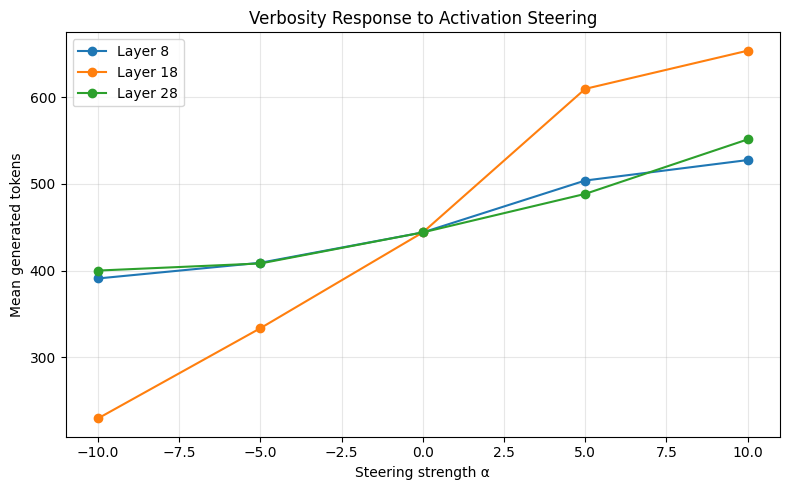

In [23]:
import matplotlib.pyplot as plt

alphas = [-10, -5, 0, 5, 10]

layer8 = [391.0, 409.1, 444.1, 503.9, 527.5]
layer18 = [229.7, 333.7, 444.1, 609.6, 653.6]
layer28 = [400.1, 408.3, 444.1, 488.5, 551.3]

plt.figure(figsize=(8, 5))

plt.plot(alphas, layer8, marker="o", label="Layer 8")
plt.plot(alphas, layer18, marker="o", label="Layer 18")
plt.plot(alphas, layer28, marker="o", label="Layer 28")

plt.xlabel("Steering strength α")
plt.ylabel("Mean generated tokens")
plt.title("Verbosity Response to Activation Steering")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [26]:
plt.savefig("results/verbosity_by_layer.png", dpi=200, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>